In [8]:
from config_feature_test import FEATURES, LABEL
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Trainings- und Testdaten laden
train_df = pd.read_parquet('train_block.parquet')
test_df = pd.read_parquet('test_block.parquet')

In [9]:
# Label umwandeln: 'attack' → 1, 'benign' → 0
train_df[LABEL] = train_df[LABEL].map({'attack': 1, 'benign': 0})
test_df[LABEL] = test_df[LABEL].map({'attack': 1, 'benign': 0})

# Features und Label auswählen
X_train = train_df[FEATURES]
y_train = train_df[LABEL]
X_test = test_df[FEATURES]
y_test = test_df[LABEL]

# Features skalieren (Scaler auf Trainingsdaten fitten, auf beide anwenden)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
test_df.head()

,timestamp,ase_spec,br_immed_spec,br_indirect_spec,br_mis_pred,br_pred,br_return_spec,branch-load-misses,branch-loads,branch-misses,...,writeback_writeback_single_inode,writeback_writeback_single_inode_start,writeback_writeback_start,writeback_writeback_wait,writeback_writeback_wait_iff_congested,writeback_writeback_wake_background,writeback_writeback_write_inode,writeback_writeback_written,attack,Label
0,2025-07-22T19:53:10,847.0,540525.0,115706.0,15452.0,656131.0,96680.0,15185.0,651088.0,14893.0,...,549617,549617,1336098,0,0,210,472963,1336098,benign,0
1,2025-07-22T19:53:20,808.0,527069.0,112884.0,14933.0,639855.0,94312.0,14941.0,640294.0,14456.0,...,549628,549628,1336113,0,0,210,472972,1336113,benign,0
2,2025-07-22T19:53:30,844.0,537613.0,115032.0,15021.0,652547.0,96070.0,14841.0,642126.0,15904.0,...,549640,549640,1336127,0,0,210,472982,1336127,benign,0
3,2025-07-22T19:53:40,879.0,530950.0,113144.0,14686.0,643996.0,94525.0,14882.0,640138.0,15161.0,...,549650,549650,1336139,0,0,210,472991,1336139,benign,0
4,2025-07-22T19:53:50,872.0,533494.0,113819.0,14967.0,647215.0,95060.0,14997.0,650649.0,14580.0,...,549654,549654,1336149,0,0,210,472995,1336149,benign,0


In [12]:
import numpy as np

def create_sequences(X, y, window_size=10):
    X_seq = []
    y_seq = []
    for i in range(len(X) - window_size + 1):
        label_window = y[i:i+window_size]
        
        # Only keep sequences where all labels in the window are the same
        if np.all(label_window == label_window[0]):
            X_seq.append(X[i:i+window_size])     # Add sequence window of features
            y_seq.append(label_window[0])        # Add corresponding consistent label
    return np.array(X_seq), np.array(y_seq)

In [13]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, window_size=10)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, window_size=10)

print(X_train_seq.shape)  # (Anzahl Fenster, 10, Anzahl Features)
print(y_train_seq.shape)  # (Anzahl Fenster,)


(4586, 10, 20)
(4586,)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Function to create a stacked LSTM model
def create_lstm_model(num_features):
    model = Sequential([
        # First LSTM layer (returns full sequences for stacking)
        LSTM(30, input_shape=(10, num_features), return_sequences=True),
        Dropout(0.2),  # Dropout to prevent overfitting
        # Second LSTM layer (only returns final output)
        LSTM(15),
        Dropout(0.2),  # Additional regularization
        # Output layer for binary classification
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model with binary crossentropy loss and accuracy metric
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

# Create model with number of selected input features
model = create_lstm_model(len(FEATURES))

# Print model summary
model.summary()

# Print number of selected features
print(len(FEATURES))

/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/bachelor/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 30)         │         6,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 15)             │         2,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,896 (34.75 KB)

 Trainable params: 8,896 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

20


In [13]:
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9958 - loss: 0.0088 - val_accuracy: 0.9103 - val_loss: 0.5962
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9979 - loss: 0.0070 - val_accuracy: 0.9077 - val_loss: 0.6470
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9978 - loss: 0.0076 - val_accuracy: 0.9088 - val_loss: 0.6535
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9981 - loss: 0.0046 - val_accuracy: 0.9051 - val_loss: 0.8312
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9970 - loss: 0.0206 - val_accuracy: 0.9088 - val_loss: 0.3231
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9155 - val_loss: 0.4570
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9979 - loss: 0.0055 - val_accuracy: 0.9093 - val_loss: 0.4453
Epoch 8/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.

In [14]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Vorhersage für Sequenzdaten
y_pred_prob = model.predict(X_test_seq)

# 2. Wahrscheinlichkeiten zu Klassenlabels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Genauigkeit und Klassifikationsbericht (jetzt gleiche Länge!)
accuracy = accuracy_score(y_test_seq, y_pred)
report = classification_report(y_test_seq, y_pred)

# 4. Ausgabe
print(f"Genauigkeit: {accuracy:.4f}")
print(report)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Genauigkeit: 0.9171
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1676
           1       0.83      0.47      0.60       253

    accuracy                           0.92      1929
   macro avg       0.87      0.73      0.77      1929
weighted avg       0.91      0.92      0.91      1929



61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1651   25]
 [ 135  118]]


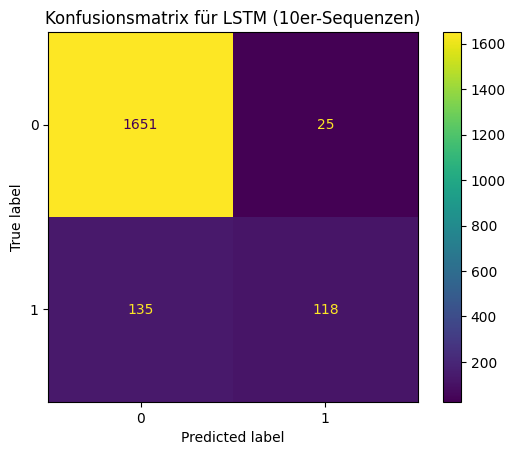

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Vorhersagen für die Testdaten erstellen – ACHTUNG: _seq benutzen!
y_pred_seq = (model.predict(X_test_seq) > 0.5).astype(int).flatten()

# 2. Konfusionsmatrix berechnen – die Längen passen jetzt!
cm = confusion_matrix(y_test_seq, y_pred_seq)

# 3. Konfusionsmatrix als Zahlen ausgeben
print(cm)

# 4. Konfusionsmatrix als Grafik anzeigen
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Konfusionsmatrix für LSTM (10er-Sequenzen)')
plt.show()


In [16]:
# Annahme: Du hast bereits diese Arrays für die Sequenzdaten:
# X_test_seq (Form: [Anzahl_Fenster, 10, n_features])
# y_test_seq (Form: [Anzahl_Fenster,])
# y_pred_seq (Form: [Anzahl_Fenster,])

# Damit der Angriffstyp zum Fenster passt:
# Nimm für jedes Fenster das Label der ERSTEN Zeile
window_size = 10

attack_seq = []
attack_array = test_df["attack"].values
for i in range(len(attack_array) - window_size + 1):
    window_labels = y_test.values[i:i+window_size]
    # Fenster nur aufnehmen, wenn alle Labels gleich (wie vorher schon beim Sequenzbau!)
    if np.all(window_labels == window_labels[0]):
        # Greife den Angriffstyp der ersten Zeile im Fenster
        attack_seq.append(attack_array[i])

attack_seq = np.array(attack_seq)  # jetzt genauso lang wie y_test_seq und y_pred_seq

# DataFrame bauen
df = pd.DataFrame({
    "y_true": y_test_seq,
    "y_pred": y_pred_seq,
    "attack": attack_seq
})

# Falsch klassifizierte Angriffe filtern (echte Angriffe als benign erkannt)
mask = (df["y_true"] == 1) & (df["y_pred"] == 0)
falsch_klassifizierte = df[mask]
print(falsch_klassifizierte["attack"].value_counts())


attack
osfingerprinting    48
aggressivescan      41
slowloris           32
portscan            14
Name: count, dtype: int64


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


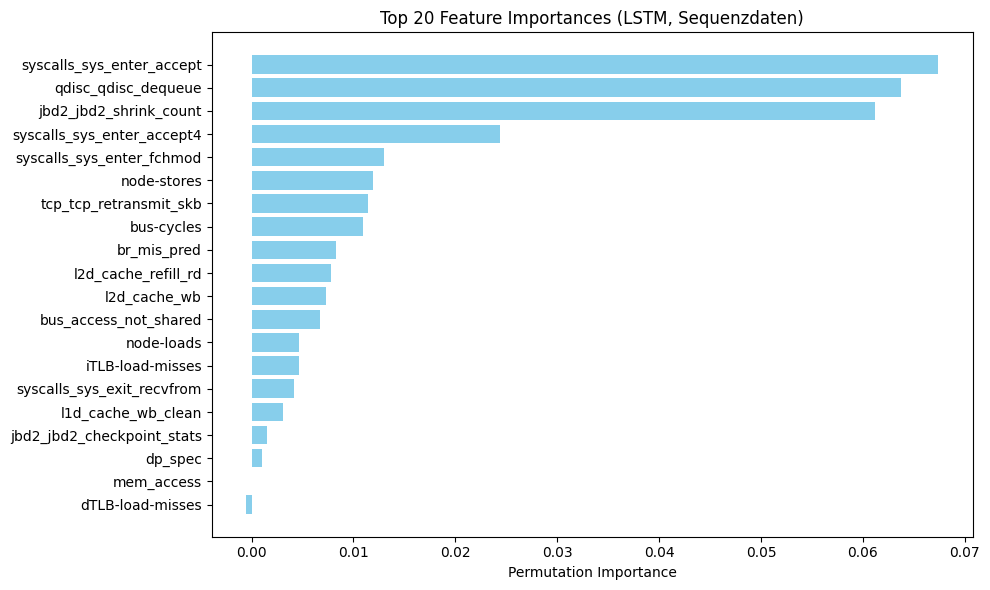

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Annahme: model, X_test_seq, y_test_seq, FEATURES sind bereits definiert

# 1. Baseline-Genauigkeit für das sequenzierte Testset
y_pred_seq = model.predict(X_test_seq)
original_acc = accuracy_score(y_test_seq, (y_pred_seq > 0.5).astype(int))

feature_importances = []
for i in range(X_test_seq.shape[2]):
    X_test_perm = X_test_seq.copy()
    # Shuffle das i-te Feature über alle Fenster und Zeitschritte
    np.random.shuffle(X_test_perm[:, :, i])
    y_pred_perm = model.predict(X_test_perm)
    perm_acc = accuracy_score(y_test_seq, (y_pred_perm > 0.5).astype(int))
    feature_importances.append(original_acc - perm_acc)

# 2. Top 20 Features finden
indices_top20 = np.argsort(feature_importances)[-20:][::-1]
top20_features = [FEATURES[i] for i in indices_top20]
top20_importances = [feature_importances[i] for i in indices_top20]

# 3. Balkendiagramm zeichnen
plt.figure(figsize=(10, 6))
plt.barh(top20_features[::-1], top20_importances[::-1], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Top 20 Feature Importances (LSTM, Sequenzdaten)')
plt.tight_layout()
plt.show()


In [18]:
print(top20_features)


['syscalls_sys_enter_accept', 'qdisc_qdisc_dequeue', 'jbd2_jbd2_shrink_count', 'syscalls_sys_enter_accept4', 'syscalls_sys_enter_fchmod', 'node-stores', 'tcp_tcp_retransmit_skb', 'bus-cycles', 'br_mis_pred', 'l2d_cache_refill_rd', 'l2d_cache_wb', 'bus_access_not_shared', 'node-loads', 'iTLB-load-misses', 'syscalls_sys_exit_recvfrom', 'l1d_cache_wb_clean', 'jbd2_jbd2_checkpoint_stats', 'dp_spec', 'mem_access', 'dTLB-load-misses']


In [19]:
from tensorflow.keras.models import load_model
import joblib

model.save('lstm_model_20events.h5')
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [20]:
print(scaler.feature_names_in_)


['syscalls_sys_exit_recvfrom' 'bus_access_not_shared'
 'tcp_tcp_retransmit_skb' 'jbd2_jbd2_checkpoint_stats' 'l2d_cache_wb'
 'jbd2_jbd2_shrink_count' 'qdisc_qdisc_dequeue'
 'syscalls_sys_enter_accept4' 'syscalls_sys_enter_accept' 'node-loads'
 'bus-cycles' 'iTLB-load-misses' 'dTLB-load-misses' 'node-stores'
 'l1d_cache_wb_clean' 'syscalls_sys_enter_fchmod' 'dp_spec'
 'l2d_cache_refill_rd' 'br_mis_pred' 'mem_access']
